# Notebook 06 — XGBoost Baseline Model

## Purpose
Establish a tabular, non-graph baseline before evaluating any graph-based 
model. This directly tests the project's core premise from the panel 
critique in notebook 00: does graph structure add value over engineered 
tabular features, or does a strong baseline already capture the signal?

## Inputs
- `data/processed/filtered_transactions.csv`

## Key engineered feature
`errorBalanceOrig` — the discrepancy between expected and actual balance 
change, a well-known strong signal in PaySim specifically (the simulator's 
bookkeeping leaves a tell when fraud occurs).

## Evaluation
Precision, recall, F1 — NOT accuracy, per the class imbalance finding in 
notebook 01 (fraud rate 0.30% in the filtered dataset).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                               classification_report, confusion_matrix,
                               precision_recall_curve, average_precision_score)

df = pd.read_csv('../data/processed/filtered_transactions.csv')
print(f"Dataset shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.4f}%")

Dataset shape: (2770393, 11)
Fraud rate: 0.2959%


In [2]:
# Engineered features for the tabular baseline

# The famous PaySim balnace discrepany

df['errorBalanceOrig'] = df['oldbalanceOrg']-df['amount']-df['newbalanceOrig']
df['errorBalanceDest'] = df['oldbalanceDest']-df['amount']-df['newbalanceDest']

# One-hot encode transaction transaction type
df['type_TRANSFER'] = (df['type'] == 'TRANSFER').astype(int)
df['type_CASH_OUT'] = (df['type'] == 'CASH_OUT').astype(int)

# Check the new features
print(df[['errorBalanceOrig', 'errorBalanceDest', 'type_TRANSFER', 'type_CASH_OUT']].describe())

       errorBalanceOrig  errorBalanceDest  type_TRANSFER  type_CASH_OUT
count      2.770393e+06      2.770393e+06   2.770393e+06   2.770393e+06
mean      -2.859866e+05     -6.637232e+05   1.923586e-01   8.076414e-01
std        8.753252e+05      1.999625e+06   3.941533e-01   3.941533e-01
min       -9.244552e+07     -1.848910e+08   0.000000e+00   0.000000e+00
25%       -2.798916e+05     -6.338166e+05   0.000000e+00   1.000000e+00
50%       -1.435988e+05     -3.499763e+05   0.000000e+00   1.000000e+00
75%       -5.185371e+04     -1.668203e+05   0.000000e+00   1.000000e+00
max        1.000000e-02      9.385210e+06   1.000000e+00   1.000000e+00


In [3]:
# Does errorBalanceOrig actually differ between fraud and normal transactions?
print("errorBalanceOrig by class:")
print(df.groupby('isFraud')['errorBalanceOrig'].describe())

print("\nerrorBalanceDest by class:")
print(df.groupby('isFraud')['errorBalanceDest'].describe())


errorBalanceOrig by class:
             count           mean            std          min         25%  \
isFraud                                                                     
0        2762196.0 -286803.509954  876375.192156 -92445516.64 -280466.255   
1           8197.0  -10713.195974  265404.389063 -10000000.00       0.000   

                50%       75%           max  
isFraud                                      
0       -144200.825 -52613.43  1.000000e-02  
1             0.000      0.00  3.725290e-09  

errorBalanceDest by class:
             count          mean           std           min           25%  \
isFraud                                                                      
0        2762196.0 -6.591413e+05  1.989672e+06 -1.848910e+08 -6.325571e+05   
1           8197.0 -2.207726e+06  3.871548e+06 -2.411357e+07 -2.189170e+06   

               50%         75%         max  
isFraud                                     
0       -349666.06 -166798.455  9385209.86  
1   

errorBalanceOrig: near-perfectly 0 for fraud (median=0, max~0), highly variable 
for normal (median=-144,200). Strongest tabular signal found so far.
Known PaySim artefact: simulator's fraud-generation logic updates origin 
balance cleanly; legitimate CASH_OUT/TRANSFER logic doesn't reconcile as neatly.
Caveat for README: may not generalise to real fraud data — flag honestly.
errorBalanceDest: opposite pattern — larger errors for fraud, consistent with 
fraud receivers collecting from multiple sources (notebook 01 finding).

In [4]:
# Define features and target
feature_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 
                 'oldbalanceDest', 'newbalanceDest',
                 'errorBalanceOrig', 'errorBalanceDest',
                 'type_TRANSFER', 'type_CASH_OUT']

X = df[feature_cols]
y = df['isFraud']

# Stratified split — preserves the fraud ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}, fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test set: {X_test.shape}, fraud rate: {y_test.mean()*100:.4f}%")

Train set: (2216314, 9), fraud rate: 0.2959%
Test set: (554079, 9), fraud rate: 0.2958%


In [6]:
import xgboost as xgb

# Handle class imbalance via scale_pos_weight
# This tells XGBoost to weight the rare fraud class more heavily during training
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr'
)

model.fit(X_train, y_train)
print("Model trained successfully")

scale_pos_weight: 336.96
Model trained successfully


In [7]:
# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Core metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
avg_precision = average_precision_score(y_test, y_pred_proba)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"PR-AUC:    {avg_precision:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Precision: 0.8987
Recall:    0.9963
F1 Score:  0.9450
PR-AUC:    0.9958

Full classification report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    552440
       Fraud       0.90      1.00      0.95      1639

    accuracy                           1.00    554079
   macro avg       0.95      1.00      0.97    554079
weighted avg       1.00      1.00      1.00    554079


Confusion matrix:
[[552256    184]
 [     6   1633]]


            feature  importance
5  errorBalanceOrig    0.781813
2    newbalanceOrig    0.177040
0            amount    0.018289
1     oldbalanceOrg    0.015746
3    oldbalanceDest    0.003180
4    newbalanceDest    0.002083
6  errorBalanceDest    0.001374
7     type_TRANSFER    0.000474
8     type_CASH_OUT    0.000000


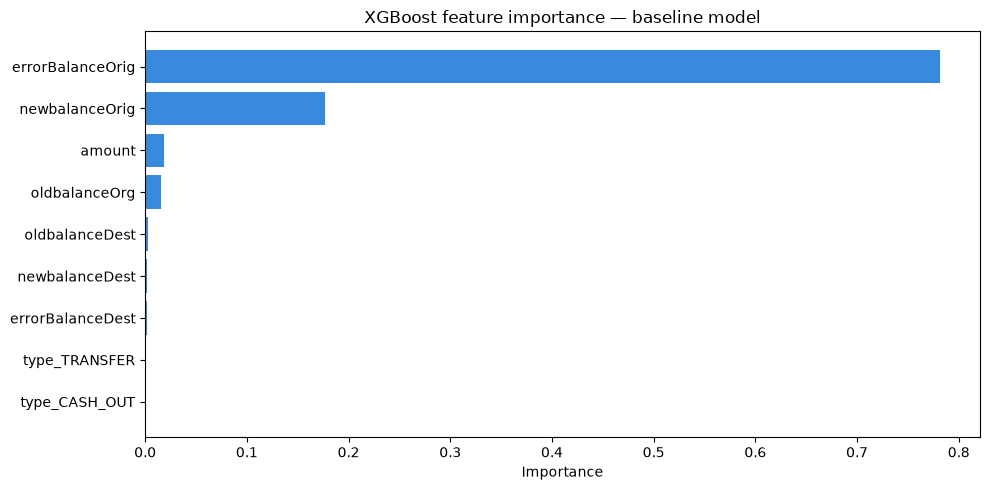

In [8]:
# Feature importance — which features is the model actually relying on?
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

plt.figure(figsize=(10, 5))
plt.barh(importance['feature'], importance['importance'], color='#378ADD')
plt.xlabel('Importance')
plt.title('XGBoost feature importance — baseline model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../results/figures/xgboost_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Baseline WITHOUT the balance-error features — isolates whether graph 
# structure could add value beyond what's already trivially available

feature_cols_no_error = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                          'oldbalanceDest', 'newbalanceDest',
                          'type_TRANSFER', 'type_CASH_OUT']

X_no_error = df[feature_cols_no_error]
X_train_ne, X_test_ne, y_train_ne, y_test_ne = train_test_split(
    X_no_error, y, test_size=0.2, random_state=42, stratify=y
)

model_no_error = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='aucpr'
)
model_no_error.fit(X_train_ne, y_train_ne)

y_pred_ne = model_no_error.predict(X_test_ne)
y_pred_proba_ne = model_no_error.predict_proba(X_test_ne)[:, 1]

print(f"Precision: {precision_score(y_test_ne, y_pred_ne):.4f}")
print(f"Recall:    {recall_score(y_test_ne, y_pred_ne):.4f}")
print(f"F1 Score:  {f1_score(y_test_ne, y_pred_ne):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test_ne, y_pred_proba_ne):.4f}")

Precision: 0.2808
Recall:    0.9951
F1 Score:  0.4380
PR-AUC:    0.9398


Baseline WITH errorBalanceOrig: P=0.90, R=1.00, F1=0.945 — dominated by 
simulator artefact (78% feature importance), likely won't generalise
Baseline WITHOUT errorBalanceOrig: P=0.28, R=1.00, F1=0.438 — high recall 
maintained but precision collapses without the balance-error signal
This precision gap is exactly where graph structure (in-degree=5.66 for 
fraud receivers vs 0.84 normal, from notebook 01) should add real value
Fair comparison for graph model: benchmark against the "without" baseline, 
not the artefact-inflated one